# Differentiate Real Images from Deep Fakes


This chapter covers

* Fine-tuning ResNet for classification
* Assessing model performance using a validation set
* Using the validation set to determine when to stop training
* Differentiating real images from deep fakes with the fine-tuned ResNet

We currently live in a world where digital content is rapidly generated and shared. The ability to distinguish between authentic images and manipulated or synthetically created ones has become crucial. Deep fakes—AI-generated images that convincingly mimic real people or objects—are increasingly prevalent, raising concerns about misinformation, privacy, and security. As these deep fakes grow more sophisticated, traditional methods of image verification struggle to keep up. This challenge demands innovative solutions grounded in deep learning and computer vision techniques.

This chapter aims to provide a robust approach for differentiating real images from deep fakes using a fine-tuned ResNet architecture. ResNet, known for its depth and efficiency in image classification tasks, serves as an ideal candidate for this purpose. By taking advantage of the power of transfer learning, we will adapt a pre-trained ResNet model to specialize in identifying image authenticity, significantly reducing the time and resources required compared to training a model from scratch.

In this chapter, you'll learn how to fine-tune ResNet for Classification. We begin by modifying the pre-trained ResNet model to suit our specific task: distinguishing real images from deep fakes. ResNet50 is pretrained to classify images into one of the 1000 categories such as toaster, stingray, goldfish, sandal and so on (the complete list is here https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). We'll modify the last layer in the model so there are two outputs instead of 1000 outputs from the model: the two outputs represent the probabilities of an image being real and being fake, respectively. We'll use training data to train the weights in the last layer, while keeing the weights in all other layers unchanged. 

During the training process, after each epoch of training, we'll evaluate model performance on a separate validation set. This step ensures the model is learning to generalize beyond the training data, offering insights into potential overfitting and underfitting issues. Further, we'll use the validation set to determine when to stop training. Proper training requires understanding when the model has reached its optimal state. We will explore how to use early stopping based on validation performance, avoiding overfitting and improving the model’s efficiency. Specifically, if the model stops improving after three consecutive epochs, we'll stop the training loop. 

Finally, the chapter demonstrates how to deploy the fine-tuned ResNet model to classify new images, providing a practical and effective tool for real-world applications. We apply the fine-tuned model to an unseen, out-of-sample, test subset. We'll display ten images from the test set and compare the predicted label (real or fake) with the ground truth. We'll also calculate the prediction accuracy in the entire test subset, which consists of 10000 real images and 10000 fake images. The fine-tuned model achieved an accuracy of 93.73%. 

By the end of this chapter, you will have a clear understanding of how to utilize deep learning techniques, specifically ResNet, to tackle the problem of distinguishing real images from deep fakes, equipping you with the skills needed to build and fine-tune a powerful image classification system.

# 1.    Training Dataset


The Python program in this chapter is adapted from two wonderful GitHub repositories: https://github.com/khanaabidabdal/Ai-Image-Classifier-Real-Vs-Fake-Faces and https://github.com/cyb0rg14/fake-image-detector. 

## 1.1 Download and Visualize The Training Dataset
You can download the 140k Real and Fake Faces dataset from Kaggle (https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces). Log in to your Kaggle account, download the zip file, extract the data from the zip file and place them in the folder /files/ on your computer.  

We'll first define three folers that contain the train, validation, and test subsets, respectively:

In [1]:
train_dir=r"F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\train"
val_dir=r'F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\valid'
test_dir=r"F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\test"

We can define a function to print out the number of images in each subset:

In [2]:
import os

def count_images(folder):
    for path, name, files in os.walk(folder):
        if len(files)>0:
            print(f"There are {len(files)} images in {path}.")
count_images(train_dir)
count_images(val_dir)
count_images(test_dir)

There are 50000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\train\fake.
There are 50000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\train\real.
There are 10000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\valid\fake.
There are 10000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\valid\real.
There are 10000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\test\fake.
There are 10000 images in F:\txt2imgF\REALFAKE\real_vs_fake\real-vs-fake\test\real.


As you can see, the train subset contains 50000 real images and 50000 fake iamges. The validation and test subsets each contain 10000 real images and 10000 fake iamges. 

Next, we can visualize five real images and five fake images in the train subset, as follows:

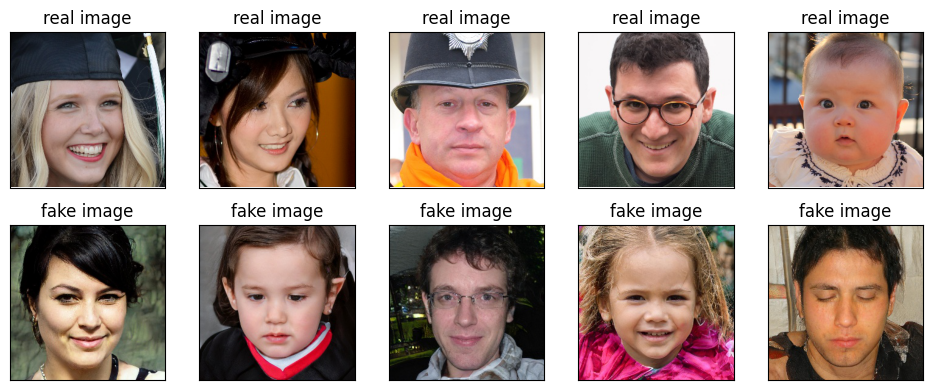

In [3]:
import glob
import matplotlib.pyplot as plt
import PIL

imgs=glob.glob(f'{train_dir}/real/*.jpg')[66:66+5]+\
    glob.glob(f'{train_dir}/fake/*.jpg')[88:88+5]

plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    img=PIL.Image.open(imgs[i])
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    if i<5:
        plt.title("real image")
    else:
        plt.title("fake image")
    plt.tight_layout()
plt.show()

The fake images look very real. It's hard to tell real images and fake images apart by just looking. We'll train a deep learning model for this purpose. 

## 1.2 Prepare the training data
We'll place the data in batches for training. 

As you'll see later, we'll fine-tune the ResNet50 to differentiate real images from fake ones. The ResNet50 transforms images in a certain way, and we therefore define a transform method as follows:

In [4]:
import torchvision

weights=torchvision.models.ResNet50_Weights.DEFAULT
transforms=weights.transforms()
print(transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


We place the train, validation, and test subsets into batches.

In [5]:
from torchvision import datasets
import torch
torch.manual_seed(42)

train_data = datasets.ImageFolder(
    root=train_dir, 
    transform=transforms, 
    target_transform=None)
val_data = datasets.ImageFolder(
    root=val_dir, 
    transform=transforms, 
    target_transform=None)
test_data = datasets.ImageFolder(
    root=test_dir,
    transform=transforms)

from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32, 
                              shuffle=True) 
val_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False) 
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=True) 

# 2 Create A Classification Model
We'll create a classifier by fine-tuning the pretrained ResNet50 model. 

ResNet50 is trained to classify images into 1000 different categories. In our setting, we want to classify images into two classes: real or fake. Therefore, we'll modify the last layer in ResNet50.  

## 2.1 Load the Pretrained ResNet50
We load the pretrained ResNet50 as follows:

In [6]:
import torch

device="cuda" if torch.cuda.is_available() else "cpu"
model=torchvision.models.resnet50(weights=weights).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

The output above shows different layers in ResNet50. In particular, the last layer has 2048 input features and 1000 output features. 

We'll freeze the weights in the pretrained ResNet50 model. We'll change the last layer and train the weights in the last layer only. 

In [7]:
for param in model.parameters():
    param.requires_grad = False

## 2.2 Change the Last Layer in ResNet50
We'll modify the last layer in ResNet50 so that there are two outputs from the model: they will represent the probabilities of an image being real and being fake, respectively. 

In [8]:
model.fc= torch.nn.Sequential(
    torch.nn.Linear(2048,1000),
    torch.nn.ReLU(),
    torch.nn.Linear(1000,500),
    torch.nn.Dropout(),
    torch.nn.Linear(in_features=500,
                    out_features=2,
                    bias=True)).to(device)

Now, we can count the number of trainable parameters and the number of nontrainable parameters in the model.

In [9]:
num_trainable=sum([p.numel() for p in model.parameters() 
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable=sum([p.numel() for p in model.parameters() 
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")

Number of trainable parameters: 2550502
Number of untrainable parameters: 23508032


The model has 2.55 million trainable parameters, which are the parameters in the last layer. The model has 23.5 million nontrainable parameters, and these are parameters in the rest of the layers in ResNet50. 

# 3.	Fine-Tune ResNet50 for Classification
We'll use the training dataset we prepared earlier to fine-tune the model. To determine when to stop training, we'll look at ther performance of the model in the validation set. We'll stop training if the model doesn't improve for three consecutive epochs. 

## 3.1 Train and Evaluate the Model
We define a train_epoch() function to train the model for one epoch:

In [10]:
from tqdm import tqdm
def train_epoch(model,dataloader,loss_fn,optimizer): 
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(tqdm(dataloader)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss/len(dataloader)

The train_epoch() function train the model for one epoch and calculate the training loss.

We define a val_epoch() function to evaluate the model using the validation data:

In [11]:
def val_epoch(model,dataloader,loss_fn):
    model.eval()
    val_loss=0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred_logits = model(X)
            loss = loss_fn(pred_logits, y)
            val_loss += loss.item()
    return val_loss/len(dataloader)

The val_epoch() function evaluate the performance of the model using validation data. The function returns the averge loss in each batch in the validation dataset.

## 3.2	The Training Loop and Early Stopping
We'll design a training loop to train the model. If the model stops improving after three epochs, we'll stop training. We'll also save the best model, based on the model's performance in the validation set. 

To implement this, we first set up the loss function and the optimizer as follows:

In [12]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

We define an early stop class as follows:

In [ ]:
class EarlyStop:
    def __init__(self, patience=3):
        self.patience = patience
        self.steps = 0
        self.min_loss = float('inf')
    def stop(self, val_loss):
        if val_loss < self.min_loss:
            self.min_loss = val_loss
            self.steps = 0
        elif val_loss >= self.min_loss:
            self.steps += 1
        if self.steps >= self.patience:
            return True
        else:
            return False
stopper=EarlyStop()

Below, we start training the model, until the model stops improving for three consecutive epochs:

In [13]:
for i in range(100):
    trainloss=train_epoch(model,train_dataloader,
        loss_fn,optimizer)
    valloss=val_epoch(model,val_dataloader,loss_fn)
    print(f'epoch {i},trainloss={trainloss},valloss={valloss}')
    if stopper.stop(valloss)==True:
        break

'''
100%|██████████| 3125/3125 [09:09<00:00,  5.69it/s]
epoch 0,trainloss=0.29766151890277864,valloss=0.2128417063266039
100%|██████████| 3125/3125 [08:47<00:00,  5.93it/s]
epoch 1,trainloss=0.2132918638330698,valloss=0.1835158979445696
100%|██████████| 3125/3125 [08:45<00:00,  5.94it/s]
epoch 2,trainloss=0.1733147142010927,valloss=0.17182585152685642
100%|██████████| 3125/3125 [08:46<00:00,  5.94it/s]
epoch 3,trainloss=0.143771453140527,valloss=0.17901243144497275
100%|██████████| 3125/3125 [08:49<00:00,  5.91it/s]
epoch 4,trainloss=0.12625390381649138,valloss=0.17306555791795253
100%|██████████| 3125/3125 [08:56<00:00,  5.83it/s]
epoch 5,trainloss=0.11259739492893218,valloss=0.1728822984278202

'''


The training takes about an hour. The training stops after six epochs. The best model is after three epochs. 

If you don't have GPU training, you can go to https://github.com/khanaabidabdal/Ai-Image-Classifier-Real-Vs-Fake-Faces to download the trained model RealityCheck.pth. 

# 4. Differentiate Real from Fake Using the Trained Model
We can now use the trained model to make out-of-sample predictions. 

## 4.1 Compare Predictions with the Ground Truth
We'll select ten images from the test subset and make predictions on them. We'll them plot each image and compare the predicted lable (real or fake) with the ground truth. 

First, we'll load the trained weights:

In [13]:
model.load_state_dict(torch.load(
r"F:\txt2imgF\REALFAKE\Ai-Image-Classifier-Real-Vs-Fake-Faces/RealityCheck.pth",
map_location=device))

C:\Users\hlliu2\AppData\Local\Temp\ipykernel_18836\2337180810.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


<All keys matched successfully>

We obtain a batch of 32 images from the test subset as follows:

In [14]:
torch.manual_seed(42)
imgs, ys = next(iter(test_dataloader))

The tensor imgs has 32 images in it. The tensor ys has 32 values in it and each value is either 0 or 1: 0 means the image is fake and 1 means the image is real.

Now we use the trained model to make predictions on the 32 images:

In [15]:
with torch.inference_mode():
    X, y = imgs.to(device), ys.to(device)
    logits = model(X)
    preds = logits.argmax(dim=1)

The tensor preds has 32 values in it and each value is either 0 or 1: 0 means the model predicts that the image is fake and 1 means that the model predicts that the image is real.

We can print out the values of ys and preds and see how they match with each other:

In [16]:
print(ys)
print(preds)
print(ys==preds.cpu())

tensor([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 1, 1, 0])
tensor([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0], device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True])


Results show that the model made 30 correct prediction and 2 wrong predictions. 

We can plot ten images and compare the predictions with the true labels. 

C:\Users\hlliu2\AppData\Local\Temp\ipykernel_18836\1800135879.py:13: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(2,5, i + 1)


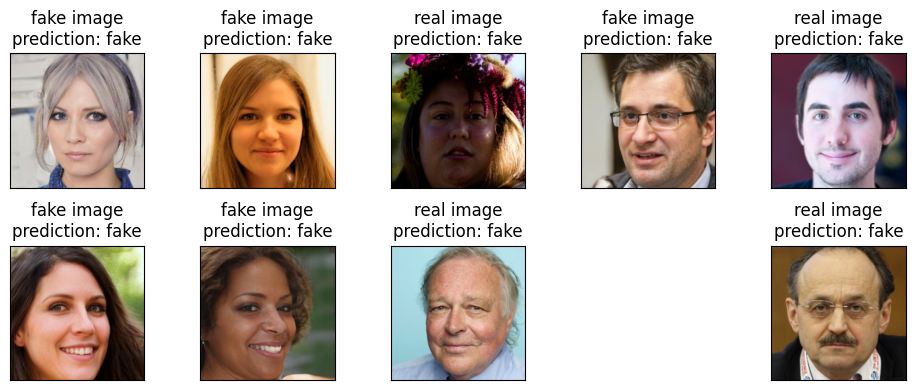

In [18]:
import torchvision.transforms as T

T1=T.Compose([
T.Normalize([0, 0, 0],
            [1/0.229, 1/0.224, 1/0.225])]) 

T2=T.Compose([
T.Normalize([-0.485, -0.456, -0.406],
            [1,1,1])]) 

plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(T2(T1(imgs[i])).permute(1,2,0))
    plt.xticks([])
    plt.yticks([])
    if preds[i]==0 and ys[i]==0:
        plt.title("fake image\nprediction: fake")
    elif preds[i]==1 and ys[i]==0:
        plt.title("fake image\nprediction: real")   
    elif preds[i]==0 and ys[i]==1:
        plt.title("real image\nprediction: fake")           
    elif preds[i]==1 and ys[i]==1:
        plt.title("real image\nprediction: fake")   
    plt.tight_layout()
plt.show()

## 4.2 Prediction Accuracy in the Test Set
We'll calculate the overall accuracy of the trained model in the test subset. 

In [23]:
model.eval()
test_acc = 0
with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(device), y.to(device)
        test_pred_logits = model(X)
        test_pred_labels = test_pred_logits.argmax(dim=1)
        test_acc += ((test_pred_labels == y).sum(
            ).item()/len(test_pred_labels))
test_acc = test_acc / len(test_dataloader)
print(f"the prediction accuracy is {test_acc:.4f}")

the prediction accuracy is 0.9373


The model classifies 93.73% of the images correctly as either real or fake. Since the test set has equal number of real and fake samples, using accuracy is the best measure. 